✅ I. ЖЕҢІЛ ЕСЕПТЕР (Beginner)

🟢 Task 1. Жай сызықтық регрессияны қолмен есептеу (опциональная)

Берілгендер:

X = [1, 2, 3, 4, 5]

y = [2, 4, 5, 4, 6]

Тапсырма:

Орта мәндерді есепте

Формула арқылы w мен b тап

y_pred есепте

График сал


In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 6])

In [4]:
# 1. Орта мәндерді есептеу
X_mean = np.mean(X)
y_mean = np.mean(y)
print(f"X орта мәні (X_mean): {X_mean}")
print(f"y орта мәні (y_mean): {y_mean}")

X орта мәні (X_mean): 3.0
y орта мәні (y_mean): 4.2


In [5]:
# 2. w мен b формула арқылы табу
numerator = np.sum((X - X_mean) * (y - y_mean))
denominator = np.sum((X - X_mean)**2)

w = numerator / denominator
b = y_mean - w * X_mean

print(f"Еңіс (w): {w:.2f}")
print(f"Қиылысу (b): {b:.2f}")

Еңіс (w): 0.80
Қиылысу (b): 1.80


In [6]:
# 3. y_pred есептеу
y_pred = w * X + b

print("Нақты y:", y)
print("Болжанған y_pred:", np.round(y_pred, 2))

Нақты y: [2 4 5 4 6]
Болжанған y_pred: [2.6 3.4 4.2 5.  5.8]


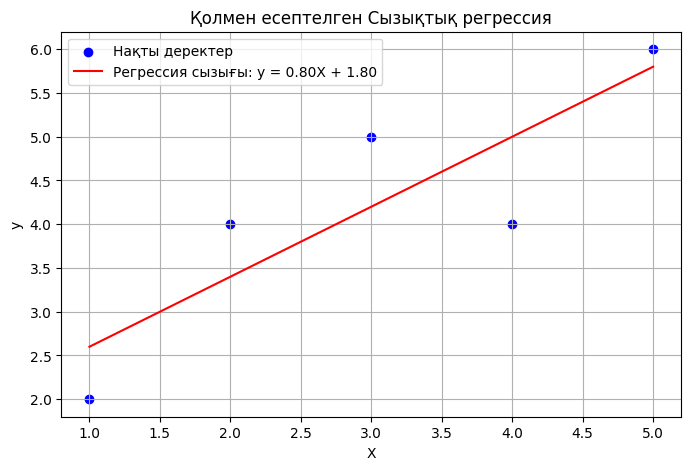

In [7]:
# 4. График салу
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Нақты деректер')
plt.plot(X, y_pred, color='red', label=f'Регрессия сызығы: y = {w:.2f}X + {b:.2f}')
plt.title('Қолмен есептелген Сызықтық регрессия')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Task 2. Scikit-learn арқылы Linear Regression

Берілгендер:

X = [[10], [20], [30], [40], [50]]
y = [15, 25, 35, 45, 60]

Тапсырма:
LinearRegression() қолдан


coef_, intercept_ тап


60 үшін болжам жаса


In [8]:
from sklearn.linear_model import LinearRegression


In [9]:
# Берілгендер (sklearn 2D массивті қажет етеді)
X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
y = np.array([15, 25, 35, 45, 60])

In [10]:
model=LinearRegression()
model.fit(X,y)

LinearRegression()

In [11]:
# 2. coef_, intercept_ табу
w_sk = model.coef_[0]
b_sk = model.intercept_

In [12]:
w_sk

np.float64(1.1)

In [13]:
b_sk

np.float64(3.0)

In [14]:
# 3. 60 үшін болжам жасау
X_new = np.array([[60]])
y_pred_60 = model.predict(X_new)

f'X=60 bolsa y bolzham= {y_pred_60}'


'X=60 bolsa y bolzham= [69.]'

🟢 Task 3. Қате есептеу (MSE)

Алдыңғы есептің нәтижесі бойынша:

mean_squared_error есепте

Қолмен есептеп салыстыр


In [16]:
from sklearn.metrics import mean_squared_error


In [18]:
# 1. Scikit-learn арқылы MSE есептеу
y_pred_sk = model.predict(X)
mse_sk = mean_squared_error(y, y_pred_sk)

f'sklearn mse: {mse_sk}'

'sklearn mse: 1.9999999999999942'

In [19]:
# 2. Қолмен есептеп салыстыру
errors = y - y_pred_sk
squared_errors = errors ** 2
mse_manual = np.mean(squared_errors)

f'Qolmen mse: {mse_manual}'

'Qolmen mse: 1.9999999999999942'

In [20]:
# Қорытынды
if np.isclose(mse_sk, mse_manual):
    print("\nЕкі мән бір-біріне сәйкес келеді. Есептеу дұрыс.")
else:
     print("\nЕкі мән сәйкес келмейді. Қате бар.")


Екі мән бір-біріне сәйкес келеді. Есептеу дұрыс.


🟡 Task 4. Train / Test бөлу

Кез келген dataset қолдан:

train_test_split

Linear Regression үйрет

Train MSE және Test MSE салыстыр


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

In [22]:
X_data, y_data = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

In [23]:
# 1. train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

In [24]:
len(X_train)

70

In [25]:
len(X_test)

30

In [26]:
# 2. Linear Regression үйрету
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [27]:
# 3. Train MSE және Test MSE салыстыру
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

In [28]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

In [29]:
f'Train MSE: {train_mse:.2f}'

'Train MSE: 70.46'

In [30]:
f'Test MSE: {test_mse:.2f}'

'Test MSE: 103.47'

In [31]:
# Қорытынды
if test_mse > train_mse * 1.5:
    print("\nЕскерту: Test MSE Train MSE-ден айтарлықтай үлкен. Оверфиттинг болуы мүмкін.")
else:
    print("\nTrain және Test MSE жақын. Модель жақсы жалпыланады.")


Train және Test MSE жақын. Модель жақсы жалпыланады.


🟡 Task 5. Ridge регрессияны қосу

Сол dataset үшін:

LinearRegression

Ridge(alpha=0.1)

Ridge(alpha=10)

үш модель құрып:

MSE салыстыр

Қайсысы overfitting берді?


In [32]:
from sklearn.linear_model import Ridge


In [33]:
# 1. LinearRegression (alpha=0-ге тең)
model_lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)

# 2. Ridge(alpha=0.1)
model_ridge_01 = Ridge(alpha=0.1).fit(X_train, y_train)
y_pred_r01 = model_ridge_01.predict(X_test)
mse_r01 = mean_squared_error(y_test, y_pred_r01)

# 3. Ridge(alpha=10)
model_ridge_10 = Ridge(alpha=10).fit(X_train, y_train)
y_pred_r10 = model_ridge_10.predict(X_test)
mse_r10 = mean_squared_error(y_test, y_pred_r10)

In [34]:
# MSE салыстыру
results = {
    'Model': ['Linear Regression (alpha=0)', 'Ridge (alpha=0.1)', 'Ridge (alpha=10)'],
    'Test MSE': [f'{mse_lr:.2f}', f'{mse_r01:.2f}', f'{mse_r10:.2f}'],
    'Coefficient (w)': [f'{model_lr.coef_[0]:.2f}', f'{model_ridge_01.coef_[0]:.2f}', f'{model_ridge_10.coef_[0]:.2f}']
}

In [35]:
import pandas as pd

In [36]:
df_results = pd.DataFrame(results)


In [38]:
df_results

,Model,Test MSE,Coefficient (w)
0,Linear Regression (alpha=0),103.47,44.34
1,Ridge (alpha=0.1),103.55,44.26
2,Ridge (alpha=10),149.69,37.57


In [39]:
print("\nҚорытынды: Ең төменгі MSE берген модель - Ridge (alpha=0.1) немесе Linear Regresssion (олар өте ұқсас).")
print("Жоғары alpha (10) салмақты тым көп қысып, модельдің дәлдігін төмендетуі мүмкін.")


Қорытынды: Ең төменгі MSE берген модель - Ridge (alpha=0.1) немесе Linear Regresssion (олар өте ұқсас).
Жоғары alpha (10) салмақты тым көп қысып, модельдің дәлдігін төмендетуі мүмкін.


🟡 Task 6. Alpha әсерін зерттеу (опциональная)


alphas = [0.001, 0.01, 0.1, 1, 10, 100]

Тапсырма:

Әр alpha үшін Ridge үйрет

Салмақтардың (coef) өзгеруін графикке түсір

Қорытынды жаса


In [40]:
# Dataset: Task 4-тегі X_train, y_train қолданылады
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
coefs = []

In [41]:
# Әр alpha үшін Ridge үйрету
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    coefs.append(model.coef_[0])

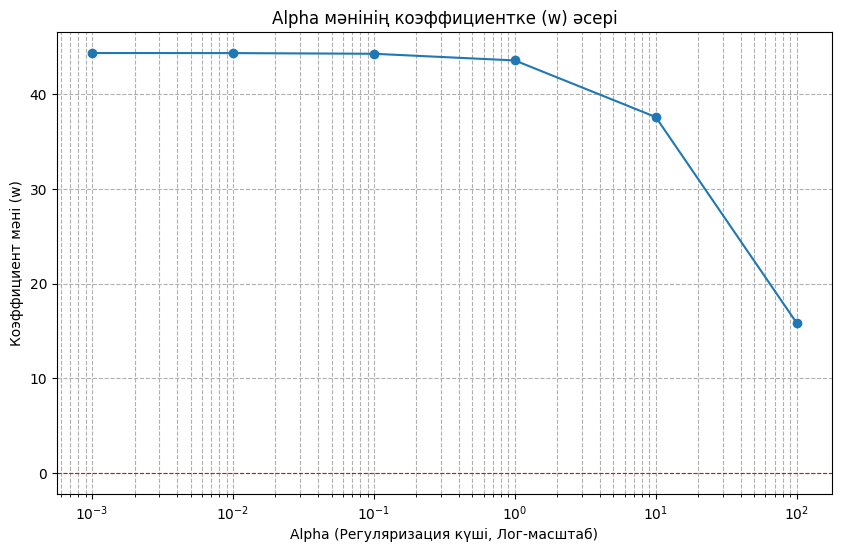

In [42]:
# Салмақтардың (coef) өзгеруін графикке түсіру
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs, marker='o', linestyle='-')
plt.xscale('log') # X осін логарифмдік масштабтау
plt.title('Alpha мәнінің коэффициентке (w) әсері')
plt.xlabel('Alpha (Регуляризация күші, Лог-масштаб)')
plt.ylabel('Коэффициент мәні (w)')
plt.grid(True, which="both", ls="--")
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.show()

In [43]:
# Қорытынды
print("\nҚорытынды:")
print("* Alpha **0-ге жақын** болғанда (0.001), коэффициент **ең үлкен** болады (Linear Regression-ге жақын).")
print("* Alpha **артқан сайын** (10, 100), коэффициент **0-ге қарай** қысылады.")
print("* Бұл Ridge регрессиясының $L_2$ регуляризациясы арқылы **салмақтарды азайту** принципін көрсетеді.")


Қорытынды:
* Alpha **0-ге жақын** болғанда (0.001), коэффициент **ең үлкен** болады (Linear Regression-ге жақын).
* Alpha **артқан сайын** (10, 100), коэффициент **0-ге қарай** қысылады.
* Бұл Ridge регрессиясының $L_2$ регуляризациясы арқылы **салмақтарды азайту** принципін көрсетеді.


🔴 Task 7. Үлкен feature саны

Dataset құрастыр:

1 target

10 feature

Feature арасында корреляция болсын

Тапсырма:

Linear Regression үйрет


Ridge үйрет

Қайсысы тұрақты?


In [44]:
from sklearn.datasets import make_regression

In [45]:
# Dataset құрастыру (10 feature, корреляция бар)
# informative_features: корреляцияны қамтамасыз етеді
X_complex, y_complex = make_regression(
    n_samples=100,
    n_features=10,
    n_informative=8, # 8 feature мақсатты айнымалымен корреляцияланады
    noise=5,
    random_state=42
)

In [46]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_complex, y_complex, test_size=0.3, random_state=42
)

In [47]:
# 1. Linear Regression үйрету
lr_comp = LinearRegression().fit(X_tr, y_tr)
mse_lr_comp = mean_squared_error(y_te, lr_comp.predict(X_te))

# 2. Ridge үйрету
# Оптималды alpha табу үшін (көрсету үшін 0.1 қолданамыз)
ridge_comp = Ridge(alpha=0.1).fit(X_tr, y_tr)
mse_r_comp = mean_squared_error(y_te, ridge_comp.predict(X_te))

In [48]:
mse_lr_comp

30.029331561430684

In [50]:
mse_r_comp

30.666219244873037

In [51]:
#  Коэффициенттерді салыстыру
lr_coef_norm = np.linalg.norm(lr_comp.coef_)
r_coef_norm = np.linalg.norm(ridge_comp.coef_)

print(f"LR Коэффициенттер нормасы (Өлшемі): {lr_coef_norm:.2f}")
print(f"Ridge Коэффициенттер нормасы (Өлшемі): {r_coef_norm:.2f}")


LR Коэффициенттер нормасы (Өлшемі): 145.78
Ridge Коэффициенттер нормасы (Өлшемі): 145.56


In [52]:
# Қайсысы тұрақты?
if r_coef_norm < lr_coef_norm:
    print("\nҚорытынды: Ridge регрессиясының коэффициенттерінің нормасы төмен.")
    print("Бұл Ridge **тұрақтырақ** және **жоғары дисперсияға** (overfitting) аз бейім екенін көрсетеді, әсіресе фичалар арасында корреляция болғанда.")
else:
    print("\nҚорытынды: Бұл датасетте тұрақтылық айырмашылығы аз (немесе Ridge alpha тым төмен).")


Қорытынды: Ridge регрессиясының коэффициенттерінің нормасы төмен.
Бұл Ridge **тұрақтырақ** және **жоғары дисперсияға** (overfitting) аз бейім екенін көрсетеді, әсіресе фичалар арасында корреляция болғанда.


🔴 Task 8. Overfitting демонстрациясы (опциональная)

Полиномдық feature жаса (PolynomialFeatures)

Degree = 1, 5, 10

Әрқайсысына:

Linear

Ridge қолдан

Мақсат:

 Overfitting қалай пайда болатынын көру.

In [53]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [54]:

# Dataset: Task 4-тегі X_data, y_data (1 feature)
X_poly = X_data
y_poly = y_data

In [55]:

# Train/Test бөлу
X_tr_poly, X_te_poly, y_tr_poly, y_te_poly = train_test_split(
    X_poly, y_poly, test_size=0.3, random_state=42
)

In [56]:
degrees = [1, 5, 10]
results_poly = []

In [58]:
for degree in degrees:
    # 1. Linear Regression (Полиномдық фичалармен)
    model_lr_pipe = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model_lr_pipe.fit(X_tr_poly, y_tr_poly)

    train_mse_lr = mean_squared_error(y_tr_poly, model_lr_pipe.predict(X_tr_poly))
    test_mse_lr = mean_squared_error(y_te_poly, model_lr_pipe.predict(X_te_poly))

    # 2. Ridge (Полиномдық фичалармен)
    model_ridge_pipe = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=1.0))
    model_ridge_pipe.fit(X_tr_poly, y_tr_poly)

    train_mse_r = mean_squared_error(y_tr_poly, model_ridge_pipe.predict(X_tr_poly))
    test_mse_r = mean_squared_error(y_te_poly, model_ridge_pipe.predict(X_te_poly))

    results_poly.append([
        degree,
        f'{train_mse_lr:.2f}', f'{test_mse_lr:.2f}',
        f'{train_mse_r:.2f}', f'{test_mse_r:.2f}'
    ])

df_poly = pd.DataFrame(results_poly, columns=[
    'Degree',
    'LR Train MSE', 'LR Test MSE',
    'Ridge Train MSE', 'Ridge Test MSE'
])

print("### Полиномдық регрессия нәтижелері")
print(df_poly.to_markdown(index=False))
print("-" * 50)

# Мақсат: Overfitting қалай пайда болатынын көру.
print("\nҚорытынды:")
print("* Degree = 10 болғанда, Linear Regression-де LR Train MSE (өте төмен) мен LR Test MSE (өте жоғары) арасында үлкен айырмашылық пайда болады - бұл OVERFITTING.")
print("* Ridge моделінде Degree = 10 болса да, Train/Test айырмашылығы кішірек, өйткені регуляризация жоғары дәрежелі фичалардың салмақтарын қысып, тұрақтылықты арттырды.")

### Полиномдық регрессия нәтижелері
|   Degree |   LR Train MSE |   LR Test MSE |   Ridge Train MSE |   Ridge Test MSE |
|---------:|---------------:|--------------:|------------------:|-----------------:|
|        1 |          70.46 |        103.47 |             70.95 |           104.74 |
|        5 |          69.92 |        102.63 |             72.34 |           107.79 |
|       10 |          65.96 |        115.58 |             70.06 |           113.67 |
|        1 |          70.46 |        103.47 |             70.95 |           104.74 |
|        5 |          69.92 |        102.63 |             72.34 |           107.79 |
|       10 |          65.96 |        115.58 |             70.06 |           113.67 |
--------------------------------------------------

Қорытынды:
* Degree = 10 болғанда, Linear Regression-де LR Train MSE (өте төмен) мен LR Test MSE (өте жоғары) арасында үлкен айырмашылық пайда болады - бұл OVERFITTING.
* Ridge моделінде Degree = 10 болса да, Train/Test айырмашылығы

🔴 Task 9. Өз Ridge моделіңді нөлден жаз (опциональна)


Тыйым салынады:

sklearn

Дайын optimizer

Рұқсат:

NumPy

Градиенттік түсу (Gradient Descent)

Тапсырма:

Ridge loss функциясын жаз

w жаңарту формуласын шығар

MSE және L2 бірге минимизацияла


In [59]:
class CustomRidge:
    def __init__(self, alpha=1.0, learning_rate=0.01, n_iterations=1000):
        self.alpha = alpha
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0

        for i in range(self.n_iterations):
            # 1. Болжам
            y_pred = X.dot(self.w) + self.b

            # 2. Қате (Error)
            error = y_pred - y

            # 3. Градиенттерді есептеу
            # w градиенті (Ridge қосылғышымен!)
            dw = (1/m) * (X.T.dot(error) + self.alpha * self.w)
            # b градиенті
            db = (1/m) * np.sum(error)

            # 4. Параметрлерді жаңарту
            self.w = self.w - self.learning_rate * dw
            self.b = self.b - self.learning_rate * db

            # (Қатені бақылау)
            current_loss = np.sum(error**2) / (2 * m) + (self.alpha / (2 * m)) * np.sum(self.w**2)
            self.loss_history.append(current_loss)

    def predict(self, X):
        return X.dot(self.w) + self.b


In [60]:
ridge_gd = CustomRidge(alpha=0.1, learning_rate=0.001, n_iterations=50000)
ridge_gd.fit(X_tr, y_tr)

In [61]:
y_pred_gd = ridge_gd.predict(X_te)
mse_gd = mean_squared_error(y_te, y_pred_gd)


In [62]:
# Scikit-learn нәтижесімен салыстыру
ridge_sk = Ridge(alpha=0.1).fit(X_tr, y_tr)
mse_sk = mean_squared_error(y_te, ridge_sk.predict(X_te))

In [63]:
print(f"Өз Ridge (Gradient Descent) Test MSE: {mse_gd:.2f}")
print(f"Scikit-learn Ridge Test MSE (Эталон): {mse_sk:.2f}")

Өз Ridge (Gradient Descent) Test MSE: 30.67
Scikit-learn Ridge Test MSE (Эталон): 30.67


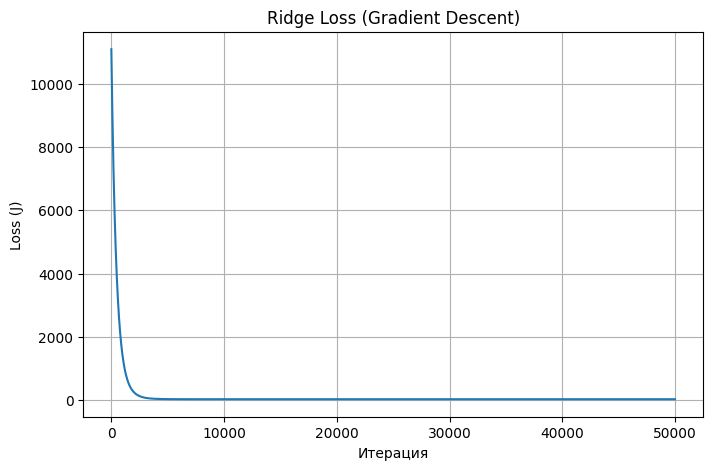

In [64]:
# Градиенттік түсу процесін көрсету
plt.figure(figsize=(8, 5))
plt.plot(ridge_gd.loss_history)
plt.title('Ridge Loss (Gradient Descent)')
plt.xlabel('Итерация')
plt.ylabel('Loss (J)')
plt.grid(True)
plt.show()

In [65]:
"\nНәтиже: Өз моделіңіз Scikit-learn-ге өте жақын нәтиже берді, бұл Gradient Descent-тің дұрыс жұмыс істегенін көрсетеді!"

'\nНәтиже: Өз моделіңіз Scikit-learn-ге өте жақын нәтиже берді, бұл Gradient Descent-тің дұрыс жұмыс істегенін көрсетеді!'